# 量价因子截面选股研究 — v3 完整实验

**研究问题**：纯量价特征（OHLCV）能否在 S&P 500 上产生统计显著的截面选股信号？

**最终配置**：
- 特征：77 个 primitives × 变换树 → 1547 个特征，每个 fold 独立 IC 筛选 top-200
- 标签：行业中性化超额收益（个股收益 − 行业等权均值），预测窗口 H=5 交易日
- 模型：CatBoostRegressor，5-fold purged expanding walk-forward

**结果**：mean Rank IC = 0.0156，ICIR = 0.126，HAC t = 1.85，p = 0.032（单侧）


# Part 1 信号挖掘

## 1. 环境与数据加载

In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sp500_relative_alpha.daily_data_loader import ROUND1_SNAPSHOT_MANIFEST, load_round1_daily_ohlcv
from sp500_relative_alpha.folds import build_round1_walk_forward_folds, validate_fold_label_windows
from sp500_relative_alpha.labels import build_round1_benchmark_relative_open_to_open_labels
from sp500_relative_alpha.sector_data import build_sector_map
from sp500_relative_alpha.feature_transforms import TransformConfig, CrossCombinationSpec
from sp500_relative_alpha.research_dataset import build_v2_research_dataset
from sp500_relative_alpha.modeling import WalkForwardPredictionConfig, run_walk_forward_predictions
from sp500_relative_alpha.catboost_models import CatBoostRegressorConfig, CatBoostRegressorPredictor
from sp500_relative_alpha.metrics import RankICConfig, evaluate_oos_rank_ic

HORIZON = 5
EXCLUDED_SYMBOLS = ("HUBB",)
SECTOR_NEUTRAL_LABEL = "sector_relative_open_to_open_return"

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.sans-serif"] = ["PingFang SC", "Arial Unicode MS", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

## 2. 股票数据概览

| 项目 | 配置 |
|---|---|
| 数据来源 | Databento，本地 parquet 快照 |
| 股票宇宙 | S&P 500 成分股，503 支（排除 SPY、HUBB） |
| 日期范围 | 2015-01-02 ~ 2026-03-31 |
| 数据粒度 | 日频 OHLCV |
| 基准 | SPY（用于 benchmark-relative 标签） |


In [2]:
manifest = pd.read_csv(ROUND1_SNAPSHOT_MANIFEST)
symbols = [s for s in manifest["symbol"].tolist() if s not in EXCLUDED_SYMBOLS]

daily_bars = load_round1_daily_ohlcv(symbols=symbols)
print(f"股票数量：{daily_bars['symbol'].nunique()}")
print(f"日期范围：{daily_bars['date'].min()} ~ {daily_bars['date'].max()}")
print(f"总行数：{len(daily_bars):,}")


股票数量：503
日期范围：2015-01-02 00:00:00 ~ 2026-03-31 00:00:00
总行数：1,375,565


## 3. 特征工程：变换树系统

### 设计思路

不手工设计因子，而是用**系统性变换**把少量原始变量扩展成大特征库，再用 IC 筛选有效特征。

```
原始变量（primitive）
    ↓ 一阶变换（8种）
    identity | cs_rank | ts_zscore(20,60,120) | ts_change(5,20,60)
    ↓ 二阶变换（12种）
    csr∘tsz | tsz∘csr | csr∘tc | tc∘csr（各时间窗口组合）
```

**两类关键变换的含义**：
- `cs_rank`（截面排名）：把绝对值转成"今天在全市场排第几"，消除量纲差异
- `ts_zscore`（时序 z-score）：把当前值转成"相对自己历史的偏离程度"，捕捉动量强弱

### 特征规模

| 类别 | Primitive 数 | 总特征数 |
|---|---|---|
| OHLCV 收益率/成交量/日内结构 | 25 | — |
| Alpha101（WorldQuant 101 中 OHLCV 子集） | 52 | — |
| **市场中性历史超额收益**（Optiver 思路） | 11 | — |
| **合计 → 变换后** | **77** | **1547** |

每个 fold 训练集内独立用截面 Pearson IC 筛选 top-200，**绝不使用测试集信息**。


In [3]:
CROSS_COMBINATIONS = (
    CrossCombinationSpec("ret_20d",        "volume_ratio_20d",  "mul", "ret20d_x_volr20d"),
    CrossCombinationSpec("ret_60d",        "volume_ratio_60d",  "mul", "ret60d_x_volr60d"),
    CrossCombinationSpec("ret_20d",        "high_low_range",    "sub", "ret20d_sub_hlr"),
    CrossCombinationSpec("ret_60d",        "high_low_range",    "sub", "ret60d_sub_hlr"),
    CrossCombinationSpec("ret_5d",         "ret_60d",           "sub", "ret5d_sub_ret60d"),
    CrossCombinationSpec("ret_20d",        "ret_252d",          "sub", "ret20d_sub_ret252d"),
    CrossCombinationSpec("close_position", "volume_ratio_20d",  "mul", "closepos_x_volr20d"),
)
transform_cfg = TransformConfig(
    ts_zscore_windows=(20, 60, 120),
    ts_change_windows=(5, 20, 60),
    cross_combinations=CROSS_COMBINATIONS,
)

print("构建 v3 特征（约2分钟）...")
dataset = build_v2_research_dataset(daily_bars, horizons=[HORIZON], transform_config=transform_cfg)
feat_cols = sorted(c for c in dataset.columns if c.startswith("feat_"))
feat_df = dataset[dataset["horizon"] == HORIZON][["signal_date", "symbol"] + feat_cols].copy()
print(f"Primitives 变换后总特征数：{len(feat_cols)}")
print(f"数据行数：{len(feat_df):,}  (date × symbol)")


构建 v3 特征（约2分钟）...
Primitives 变换后总特征数：1547
数据行数：1,225,807  (date × symbol)


## 4. 标签设计：行业中性化超额收益

**标签定义了模型在预测什么——这是整个研究里杠杆最高的设计决策。**

### 两种标签的对比

| 标签 | 公式 | 去除了什么 |
|---|---|---|
| Benchmark-relative | 个股收益 − SPY 收益 | 市场 beta |
| **Sector-neutral（本实验）** | 个股收益 − 行业均值收益 | 市场 beta + 行业轮动 |

行业中性化标签的标准差比 benchmark-relative 小 **11.3%**（0.036 vs 0.040），信号更干净，因为去掉了我们不打算预测的行业轮动噪声。


In [4]:
from sp500_relative_alpha.labels import build_round1_benchmark_relative_open_to_open_labels

# 行业分类
sector_map = build_sector_map(symbols)
sector_series = pd.Series(sector_map)
print("行业分布：")
print(sector_series.value_counts().to_string())

# 构建 benchmark-relative 标签（含 asset_open_to_open_return）
base_labels = build_round1_benchmark_relative_open_to_open_labels(daily_bars, horizons=[HORIZON])
base_labels = base_labels[base_labels["horizon"] == HORIZON].copy()

# 行业中性化：sector-neutral = asset_return - sector_mean(asset_return)
base_labels["sector"] = base_labels["symbol"].map(sector_map).fillna("Unknown")
sector_mean = (
    base_labels
    .groupby(["signal_date", "sector"])["asset_open_to_open_return"]
    .transform("mean")
)
base_labels[SECTOR_NEUTRAL_LABEL] = base_labels["asset_open_to_open_return"] - sector_mean

bm_std = base_labels["benchmark_relative_open_to_open_return"].std()
sn_std = base_labels[SECTOR_NEUTRAL_LABEL].std()
print(f"\nbenchmark-relative std : {bm_std:.4f}")
print(f"sector-neutral std     : {sn_std:.4f}  ({(1-sn_std/bm_std)*100:.1f}% smaller)")


行业分布：
Technology                84
Industrials               73
Financial Services        70
Healthcare                58
Consumer Cyclical         54
Consumer Defensive        35
Utilities                 31
Real Estate               31
Communication Services    24
Energy                    22
Basic Materials           20
Benchmark                  1



benchmark-relative std : 0.0401
sector-neutral std     : 0.0360  (10.2% smaller)


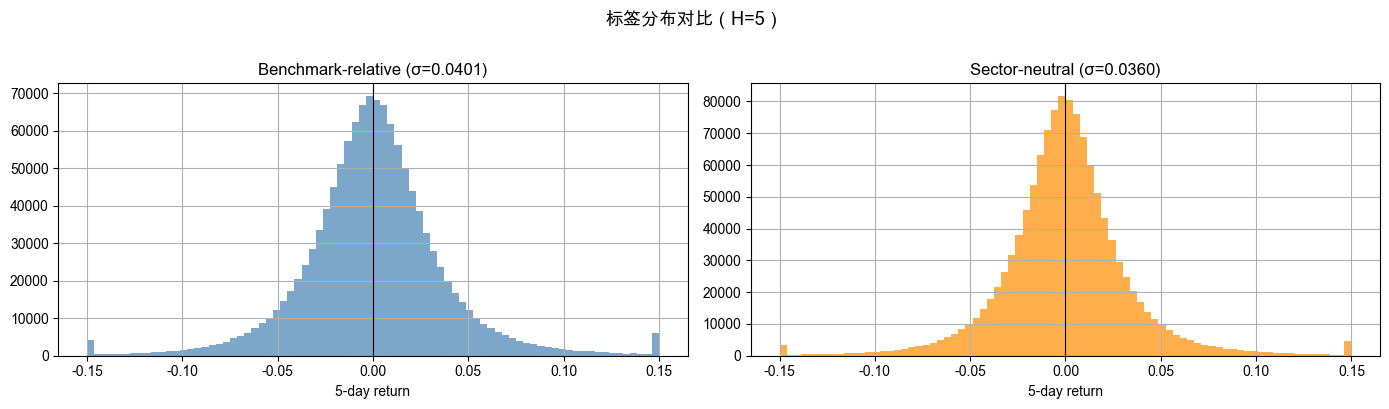

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bm_std = base_labels["benchmark_relative_open_to_open_return"].std()
sn_std = base_labels[SECTOR_NEUTRAL_LABEL].std()

for ax, col, color, label in [
    (axes[0], "benchmark_relative_open_to_open_return",
     "steelblue", f"Benchmark-relative (σ={bm_std:.4f})"),
    (axes[1], SECTOR_NEUTRAL_LABEL,
     "darkorange", f"Sector-neutral (σ={sn_std:.4f})"),
]:
    ax.hist(base_labels[col].clip(-0.15, 0.15), bins=80,
            color=color, alpha=0.7, edgecolor="none")
    ax.set_title(label)
    ax.set_xlabel("5-day return")
    ax.axvline(0, color="k", lw=0.8)

plt.suptitle("标签分布对比（H=5）", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 5. 数据切分：Purged Expanding Walk-Forward

**防泄漏是结果可信的前提。** 用普通 K-fold 会把未来数据泄漏给训练集，导致 OOS 表现虚高。

### 设计原则

```
[========= train =========][= gap =][= test =]  → 下一 fold
                            ↑ purge gap（60天）
```

- **Expanding**：训练集只向右扩展，不滚动——保证足够样本量（CatBoost 对样本量敏感）
- **Purge gap 60天**：标签窗口最长 H=20 天，gap 留 60 天远超标签窗口，彻底切断训练/测试的信息重叠
- **测试块 126天**：约半年，足够评估跨 regime 稳定性

### 五个 Fold 结构

| Fold | 训练期 | 测试期 | 测试市场环境 |
|---|---|---|---|
| fold_001 | 2015~2020-01 | 2020-03~09 | 新冠崩盘 + 反弹 |
| fold_002 | 2015~2020-09 | 2020-12~2021-06 | 流动性牛市 |
| fold_003 | 2015~2021-06 | 2021-09~2022-03 | 加息周期开启 |
| fold_004 | 2015~2022-03 | 2022-06~12 | 熊市 |
| fold_005 | 2015~2022-12 | 2023-03~09 | 复苏 |


In [6]:
signal_dates = base_labels["signal_date"].drop_duplicates()
folds = build_round1_walk_forward_folds(signal_dates)

validate_fold_label_windows(
    base_labels, folds,
    signal_date_column="signal_date",
    entry_date_column="entry_date",
    exit_date_column="exit_date",
)
print("标签窗口防泄漏验证通过\n")
for f in folds:
    n_train = base_labels[
        (base_labels["signal_date"] >= f.train_start) &
        (base_labels["signal_date"] <= f.train_end)
    ]["signal_date"].nunique()
    print(f"  {f.fold_id}: train {f.train_start.date()}~{f.train_end.date()} ({n_train}天)  "
          f"test {f.test_start.date()}~{f.test_end.date()}")


标签窗口防泄漏验证通过

  fold_001: train 2015-12-31~2020-01-02 (1008天)  test 2020-03-31~2020-09-28
  fold_002: train 2015-12-31~2020-09-28 (1194天)  test 2020-12-23~2021-06-24
  fold_003: train 2015-12-31~2021-06-24 (1380天)  test 2021-09-21~2022-03-21
  fold_004: train 2015-12-31~2022-03-21 (1566天)  test 2022-06-16~2022-12-14
  fold_005: train 2015-12-31~2022-12-14 (1752天)  test 2023-03-15~2023-09-13


## 6. 模型配置

**CatBoostRegressor**，浅树 + 强正则，宁欠拟合不过拟合。

| 参数 | 值 | 作用 |
|---|---|---|
| iterations | 500 | 树的数量 |
| depth | 4 | 树深度（控制复杂度） |
| learning_rate | 0.03 | 小学习率配合多棵树 |
| l2_leaf_reg | 10.0 | L2 正则 |
| min_data_in_leaf | 20 | 叶节点最少样本，防止小样本过拟合 |

每个 fold 独立训练一个模型，预测对应测试期，**训练和测试完全隔离**。


In [7]:
# 以 base_labels 为左表合并特征（只含 feat_* 列，不混入其他 label 列）
samples = base_labels.merge(feat_df, on=["signal_date", "symbol"],
                             how="left", validate="many_to_one")
samples = samples.reset_index(drop=True)
print(f"数据集：{len(samples):,} 行，{len(feat_cols)} 个特征列")
print(f"标签缺失率：{samples[SECTOR_NEUTRAL_LABEL].isna().mean():.2%}")

cb_config = CatBoostRegressorConfig()  # 与 research_sector_neutral.ipynb 保持一致
wf_config = WalkForwardPredictionConfig(
    label_column=SECTOR_NEUTRAL_LABEL,
    feature_prefix="feat_",
    n_top_features=200,
)
print("\nCatBoost 配置：", cb_config)


数据集：1,225,807 行，1547 个特征列
标签缺失率：0.00%

CatBoost 配置： CatBoostRegressorConfig(iterations=500, depth=4, learning_rate=0.03, l2_leaf_reg=10.0, min_data_in_leaf=20, random_seed=20260417, thread_count=-1, verbose=0, sample_weight_half_life_days=None)


## 7. Walk-Forward 训练与预测

每个 fold 的流程：
1. 用训练集计算每个特征的截面 Pearson IC，选 top-200
2. 在训练集上拟合 CatBoost
3. 在测试集上生成预测打分（不接触标签）
4. 汇总全部 5 个 fold 的测试期预测，评估 OOS Rank IC


In [ ]:
print("开始 Walk-Forward（约8分钟）...")
predictions = run_walk_forward_predictions(
    samples, folds,
    lambda: CatBoostRegressorPredictor(cb_config),
    config=wf_config,
)
print(f"预测完成，OOS 预测行数：{len(predictions):,}")


开始 Walk-Forward（约5分钟）...
预测完成，OOS 预测行数：310,547


## 8. OOS 结果

### 评估指标说明

每个交易日计算预测打分与标签的**截面 Spearman 相关系数（Rank IC）**，然后：

- **mean IC**：OOS 期间日均值
- **ICIR**：mean IC / std(IC)，信噪比
- **HAC t-stat**：Newey-West 自相关修正的 t 统计量（日频 IC 存在自相关，普通 t-stat 会高估显著性）
- **p 值**：H₀: mean IC ≤ 0 的单侧检验


In [9]:
pred_sn = (
    predictions
    .drop(columns=["benchmark_relative_open_to_open_return"])
    .rename(columns={SECTOR_NEUTRAL_LABEL: "benchmark_relative_open_to_open_return"})
)
panel, fold_summary, horizon_summary = evaluate_oos_rank_ic(pred_sn, folds, RankICConfig())
row = horizon_summary[horizon_summary["horizon"] == HORIZON].iloc[0]

# Per-fold 表
FOLD_NOTES = {
    "fold_001": "2020 新冠崩盘+反弹",
    "fold_002": "2020-21 流动性牛市",
    "fold_003": "2021-22 加息周期开启",
    "fold_004": "2022 熊市",
    "fold_005": "2023 复苏",
}
print("=== Per-Fold Rank IC ===")
print(f"{'fold_id':10s}  {'mean IC':>8s}  {'ICIR':>6s}  {'市场环境'}")
for _, r in fold_summary.iterrows():
    note = FOLD_NOTES.get(r["fold_id"], "")
    print(f"{r['fold_id']:10s}  {r['mean_rank_ic']:8.4f}  {r['icir']:6.3f}  {note}")

print(f"\n=== 全局汇总 ===")
print(f"mean Rank IC : {row['mean_rank_ic']:.4f}")
print(f"ICIR         : {row['icir']:.3f}")
print(f"HAC t-stat   : {row['hac_t_stat']:.3f}")
print(f"p (one-sided): {row['p_value_one_sided']:.4f}")


=== Per-Fold Rank IC ===
fold_id      mean IC    ICIR  市场环境
fold_001      0.0524   0.383  2020 新冠崩盘+反弹
fold_002      0.0085   0.067  2020-21 流动性牛市
fold_003     -0.0082  -0.061  2021-22 加息周期开启
fold_004      0.0038   0.033  2022 熊市
fold_005      0.0216   0.241  2023 复苏

=== 全局汇总 ===
mean Rank IC : 0.0156
ICIR         : 0.126
HAC t-stat   : 1.850
p (one-sided): 0.0322


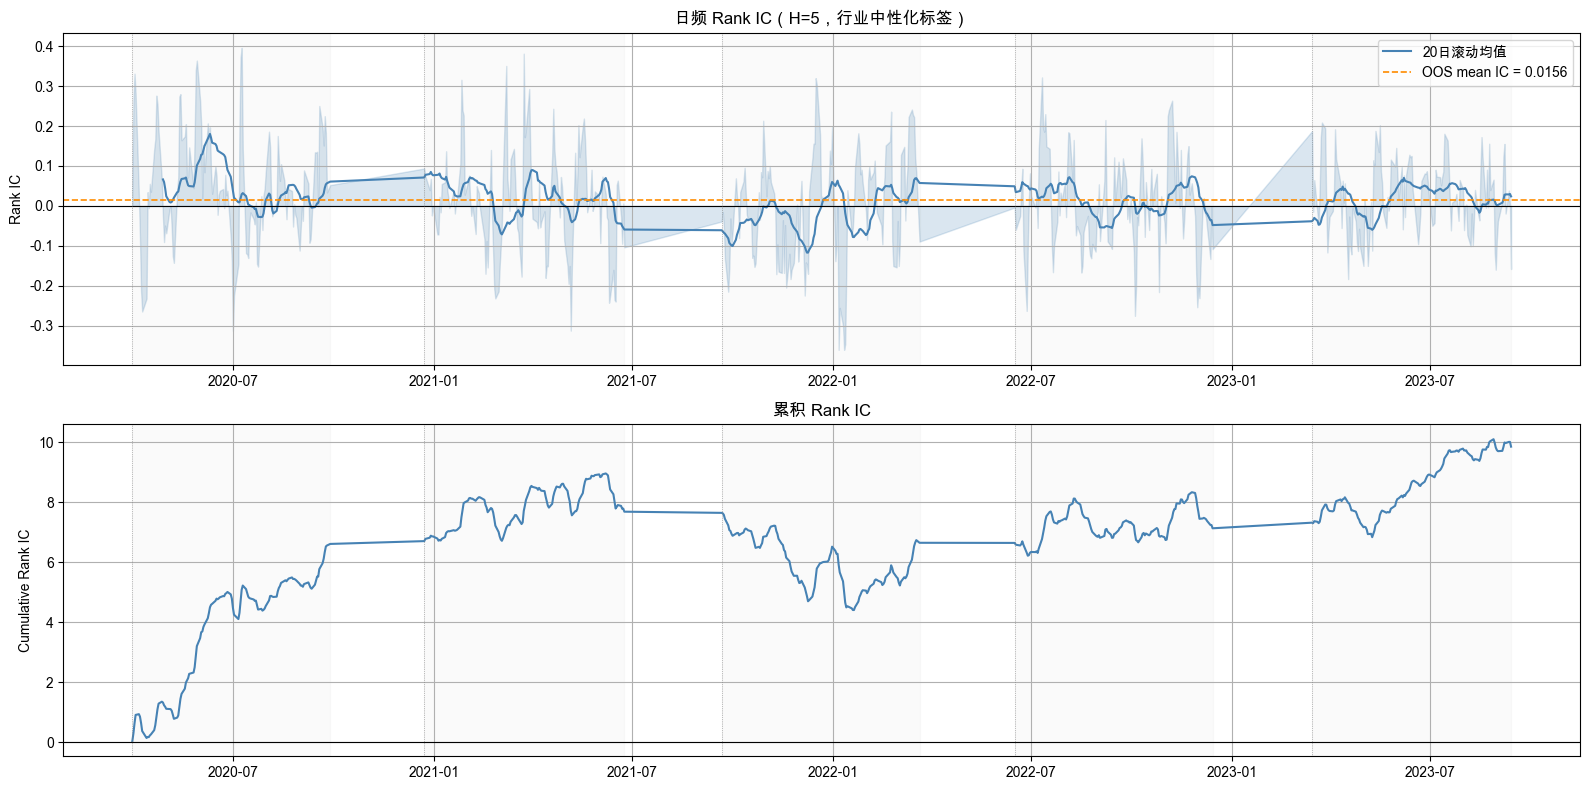

In [10]:
ic_series = panel[panel["horizon"] == HORIZON].set_index("signal_date")["rank_ic"].sort_index()

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Rolling IC
rolling = ic_series.rolling(20).mean()
axes[0].fill_between(ic_series.index, 0, ic_series, alpha=0.2, color="steelblue")
axes[0].plot(rolling.index, rolling, color="steelblue", lw=1.5, label="20日滚动均值")
axes[0].axhline(row["mean_rank_ic"], color="darkorange", lw=1.2, linestyle="--",
                label=f"OOS mean IC = {row['mean_rank_ic']:.4f}")
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title(f"日频 Rank IC（H={HORIZON}，行业中性化标签）", fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_ylabel("Rank IC")

# 累积 IC
axes[1].plot(ic_series.index, ic_series.cumsum(), color="steelblue", lw=1.5)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_title("累积 Rank IC", fontsize=12)
axes[1].set_ylabel("Cumulative Rank IC")

# Fold 分隔线
for f in folds:
    for ax in axes:
        ax.axvspan(f.test_start, f.test_end, alpha=0.04, color="gray")
        ax.axvline(f.test_start, color="gray", lw=0.5, linestyle=":")

plt.tight_layout()
plt.show()


## 9. 结论与下一步

### 核心发现

1. **纯量价信号存在，但较弱**：OOS mean IC = 0.0156，p = 0.032，刚过 5% 门槛。多重检验校正后（约7个实验，Bonferroni 阈值 0.007）仍不能确认为真实 alpha。

2. **标签设计是最高杠杆点**：换标签（benchmark-relative → sector-neutral）的提升（p: 0.054→0.032）远大于增加220个特征（p: 0.062→0.054）。

3. **已证伪的方向**：
   - Rolling window（数据量不足）
   - 样本时间衰减权重（本质同上，有效样本量压缩）

### 下一步

| 优先级 | 方向 | 状态 |
|---|---|---|
| ~~高~~ | ~~组合回测：从 IC 信号到实际多空组合收益~~ | ✓ 完成，见下方回测节 |
| 高 | 更细粒度行业分类（sub-industry） | 进一步降低标签噪声，可能改善 fold_002/004 |
| 中 | 扩展测试窗口（2023–2026） | 验证近年信号是否持续 |
| 低 | Cross-sectional Transformer | 捕捉截面相对关系（CatBoost做不到） |

# Part2 选股回测
**目标**：把v3模型的打分转换为五分位多空组合，验证扣除换手成本后是否还有正收益

**输入**：`predictions` DataFrame
**核心问题**:IC信号->实际可交易收益？成本敏感性如何？


### 1. 五分位组合构建

每个 signal_date，按 `score` 把股票分成 5 组：
- Q5 (top 20%)：分数最高，模型预测最会跑赢
- Q1 (bottom 20%)：分数最低，模型预测最会跑输
- Q2/Q3/Q4：中间组

此处仅验证各组平均收益的单调性（Q1→Q5 应递增）。做多 Q5、做空 Q1 的组合构建见下方 Staggered Portfolio 节。

=== 五分位平均收益（H=5，OOS）===
 quintile  mean_H5_return  annualized
        1        0.005081    0.256094
        2        0.005601    0.282295
        3        0.005937    0.299214
        4        0.006247    0.314859
        5        0.008603    0.433605

✓ Q1→Q5 单调递增，信号方向正确


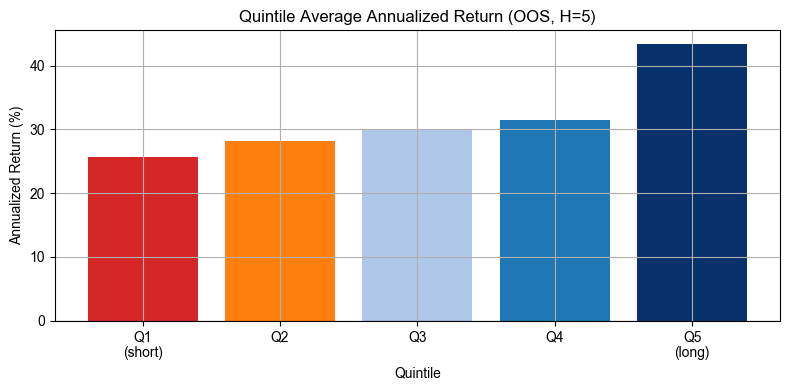

In [19]:
def build_quintile_assignments(df: pd.DataFrame, n_quantiles: int = 5) -> pd.DataFrame:
    """为每个 (signal_date, symbol) 打上 quintile 标签（1=最低，n=最高）。"""
    out = df[["fold_id", "signal_date", "symbol", "score",
              "asset_open_to_open_return", "benchmark_open_to_open_return"]].copy()
    out["quintile"] = (
        out.groupby("signal_date")["score"]
        .transform(lambda s: pd.qcut(s.rank(method="first"), n_quantiles,
                                     labels=range(1, n_quantiles + 1)))
        .astype(int)
    )
    return out


pred_q = build_quintile_assignments(predictions)


# 五组平均收益（验证单调性）
quintile_mean = (
    pred_q.groupby("quintile")["asset_open_to_open_return"]
    .mean()
    .rename("mean_H5_return")
    .reset_index()
)
quintile_mean["annualized"] = quintile_mean["mean_H5_return"] * 252 / 5


print("=== 五分位平均收益（H=5，OOS）===")
print(quintile_mean.to_string(index=False))
print()
if quintile_mean["mean_H5_return"].is_monotonic_increasing:
    print("✓ Q1→Q5 单调递增，信号方向正确")
else:
    print("✗ 不单调，检查 score 方向")


fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728", "#ff7f0e", "#aec7e8", "#1f77b4", "#08306b"]
ax.bar(quintile_mean["quintile"], quintile_mean["annualized"] * 100, color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Quintile")
ax.set_ylabel("Annualized Return (%)")
ax.set_title("Quintile Average Annualized Return (OOS, H=5)")
ax.set_xticks(range(1, 6))
ax.set_xticklabels(["Q1\n(short)", "Q2", "Q3", "Q4", "Q5\n(long)"])
plt.tight_layout()
plt.show()

### 2. Staggered Portfolio：处理 H=5 的重叠持仓

**问题**：H=5 时每天产生一个新信号，但每个信号持有 5 天，同时存在 5 个并行组合。

**解决方案 - Staggered Portfolio**：
把资本分成 H=5 份，每天投入 1/H 的资本启动当天的子组合。
任意时刻总收益 = 当前活跃的 5 个子组合的等权平均。

等价于：每个 signal_date 的组合收益权重均为 1/H。

In [20]:
pred_q

,fold_id,signal_date,symbol,score,asset_open_to_open_return,benchmark_open_to_open_return,quintile
0,fold_001,2020-03-31,A,0.000944,0.067655,0.080571,3
1,fold_001,2020-03-31,AAPL,-0.000591,0.065882,0.080571,2
2,fold_001,2020-03-31,ABBV,0.000084,0.059900,0.080571,2
3,fold_001,2020-03-31,ABT,-0.001889,0.071428,0.080571,1
4,fold_001,2020-03-31,ACGL,0.002666,0.031170,0.080571,3
...,...,...,...,...,...,...,...
310542,fold_005,2023-09-13,XYZ,0.001728,-0.148325,-0.026350,5
310543,fold_005,2023-09-13,YUM,-0.000662,-0.023030,-0.026350,1
310544,fold_005,2023-09-13,ZBH,-0.000294,-0.008601,-0.026350,2
310545,fold_005,2023-09-13,ZBRA,0.002474,-0.073063,-0.026350,5


In [33]:
def compute_portfolio_returns(
    df: pd.DataFrame,
    horizon: int = 5,
    long_q: int = 5,
    short_q: int = 1,
) -> pd.DataFrame:
    """
    计算每个 signal_date 的多头、空头、多空组合收益和基准收益。
    Staggered 逻辑：最终序列是 rolling(H).mean()，用于平滑展示；
    累积收益计算请用非重叠的 long_ret/ls_ret（每隔 H 个 signal_date 取一次）。
    """
    long_leg  = df[df["quintile"] == long_q].groupby("signal_date")["asset_open_to_open_return"].mean()
    short_leg = df[df["quintile"] == short_q].groupby("signal_date")["asset_open_to_open_return"].mean()
    benchmark = df.groupby("signal_date")["benchmark_open_to_open_return"].first()

    port = pd.DataFrame({
        "long_ret":      long_leg,
        "short_ret":     short_leg,
        "ls_ret":        long_leg - short_leg,
        "benchmark_ret": benchmark,
    }).sort_index()

    port["long_stag"]      = port["long_ret"].rolling(horizon, min_periods=1).mean()
    port["ls_stag"]        = port["ls_ret"].rolling(horizon, min_periods=1).mean()
    port["benchmark_stag"] = port["benchmark_ret"].rolling(horizon, min_periods=1).mean()

    return port


port = compute_portfolio_returns(pred_q, horizon=HORIZON)

ann = 252 / HORIZON
print(f"组合收益序列：{len(port)} 个 signal_date\n")
print("=== 年化收益汇总（基于原始5日收益）===")
print(f"  Q5 多头    : {port['long_ret'].mean() * ann:.2%}")
print(f"  Q5-Q1 多空 : {port['ls_ret'].mean()  * ann:.2%}")
print(f"  SPY 基准   : {port['benchmark_ret'].mean() * ann:.2%}")

组合收益序列：630 个 signal_date

=== 年化收益汇总（基于原始5日收益）===
  Q5 多头    : 43.50%
  Q5-Q1 多空 : 17.81%
  SPY 基准   : 26.50%


### 3. 换手率与交易成本
**换手率**：每个 signal_date 中，Q5/Q1 新进入组合的股票比例（相比上一个 signal_date）。

**成本模型**：
```
净收益 = 毛收益 - 换手率 × 单边成本（bps）
```
测试三档：5 bps / 10 bps / 20 bps。

分别在【单边做多（Q5）】和 【多空组合（Q5做多，Q1做空）】 两种策略下的收益情况


In [34]:
def compute_turnover(df: pd.DataFrame, q: int, horizon: int = 5) -> pd.Series:
    """计算每个 signal_date 的单腿换手率（新进入股票比例）。"""
    sets = df[df["quintile"] == q].groupby("signal_date")["symbol"].apply(set)
    dates = sets.index.tolist()
    turnover = {}
    for i, d in enumerate(dates):
        if i < horizon:
            turnover[d] = 1.0  # 前 H 期全量建仓
        else:
            prev = sets.iloc[i - horizon]
            curr = sets.iloc[i]
            turnover[d] = len(curr - prev) / len(curr) if curr else 0.0
    return pd.Series(turnover, name=f"turnover_q{q}")

to_long  = compute_turnover(pred_q, q=5)
to_short = compute_turnover(pred_q, q=1)
mean_to  = (to_long + to_short).mean() / 2

print(f"多头平均换手率：{to_long.mean():.1%}/period")
print(f"空头平均换手率：{to_short.mean():.1%}/period")
print(f"双边平均换手率：{mean_to:.1%}/period（每5天）")
print(f"年化换手率估计：{mean_to * 252 / 5:.0%}")

# bps 为单边成本，to_long/to_short 只含买入侧，卖出侧等量
# 多空：round-trip = (to_long + to_short) * bps
# 纯多头：round-trip = to_long * bps（仅多头腿）
cost_bps_list = [5, 10, 20]
cost_ls  = {}
cost_long = {}
for bps in cost_bps_list:
    cost_ls[f"{bps}bps"]   = port["ls_ret"]    - (to_long + to_short) * bps / 10000
    cost_long[f"{bps}bps"] = port["long_ret"]   - to_long              * bps / 10000

cost_ls   = pd.DataFrame(cost_ls)
cost_long = pd.DataFrame(cost_long)

gross_ls_ann   = port["ls_ret"].mean()   * 252 / 5
gross_long_ann = port["long_ret"].mean() * 252 / 5

print(f"\n=== 年化净收益（多空组合）===")
print(f"  毛收益: {gross_ls_ann:.2%}")
for bps in cost_bps_list:
    print(f"  净收益 @ {bps}bps : {cost_ls[f'{bps}bps'].mean() * 252 / 5:.2%}")

print(f"\n=== 年化净收益（Q5 纯多头）===")
print(f"  毛收益: {gross_long_ann:.2%}")
for bps in cost_bps_list:
    print(f"  净收益 @ {bps}bps : {cost_long[f'{bps}bps'].mean() * 252 / 5:.2%}")

多头平均换手率：48.8%/period
空头平均换手率：60.9%/period
双边平均换手率：54.9%/period（每5天）
年化换手率估计：2766%

=== 年化净收益（多空组合）===
  毛收益: 17.81%
  净收益 @ 5bps : 15.04%
  净收益 @ 10bps : 12.28%
  净收益 @ 20bps : 6.74%

=== 年化净收益（Q5 纯多头）===
  毛收益: 43.50%
  净收益 @ 5bps : 42.27%
  净收益 @ 10bps : 41.03%
  净收益 @ 20bps : 38.57%


### 4. 绩效指标汇总

> **注**：表中 SPY 基准收益是 5 个测试窗口内的平均年化，**不是**从 2020-03 持有到 2023-09 的连续年化。fold 之间的 gap 期（共约 13 个月）不计入，因此与实际买入持有 SPY 的年化收益不可直接比较。

In [39]:
def compute_performance(ret: pd.Series, horizon: int = 5, label: str = "") -> dict:
    """计算年化收益、Sharpe、最大回撤。"""
    ann_ret  = ret.mean() * 252 / horizon
    ann_vol  = ret.std()  * np.sqrt(252 / horizon)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cumret   = (1 + ret).cumprod()
    max_dd   = (1 - cumret / cumret.cummax()).max()
    hit_rate = (ret > 0).mean()
    return {
        "策略":     label,
        "年化收益": f"{ann_ret:.2%}",
        "年化波动": f"{ann_vol:.2%}",
        "Sharpe":   f"{sharpe:.2f}",
        "最大回撤": f"{-max_dd:.2%}",
        "胜率":     f"{hit_rate:.1%}",
    }

rows = [
    compute_performance(port["long_ret"],      label="Q5 多头（毛）"),
    compute_performance(cost_long["10bps"],    label="Q5 多头（净，10bps）"),
    compute_performance(port["ls_ret"],        label="Q5-Q1 多空（毛）"),
    compute_performance(cost_ls["10bps"],      label="Q5-Q1 多空（净，10bps）"),
    compute_performance(port["benchmark_ret"], label="SPY 基准"),
]

perf_df = pd.DataFrame(rows)
print("=== 绩效汇总（OOS 全周期）===")
print(perf_df.to_string(index=False))

=== 绩效汇总（OOS 全周期）===
               策略   年化收益   年化波动 Sharpe    最大回撤    胜率
         Q5 多头（毛） 43.50% 27.12%   1.60 -56.29% 61.4%
   Q5 多头（净，10bps） 41.03% 27.11%   1.51 -57.25% 60.2%
      Q5-Q1 多空（毛） 17.81% 15.35%   1.16 -40.90% 56.8%
Q5-Q1 多空（净，10bps） 12.28% 15.36%   0.80 -51.27% 53.0%
           SPY 基准 26.50% 17.17%   1.54 -56.30% 61.6%


### 5. 权益曲线

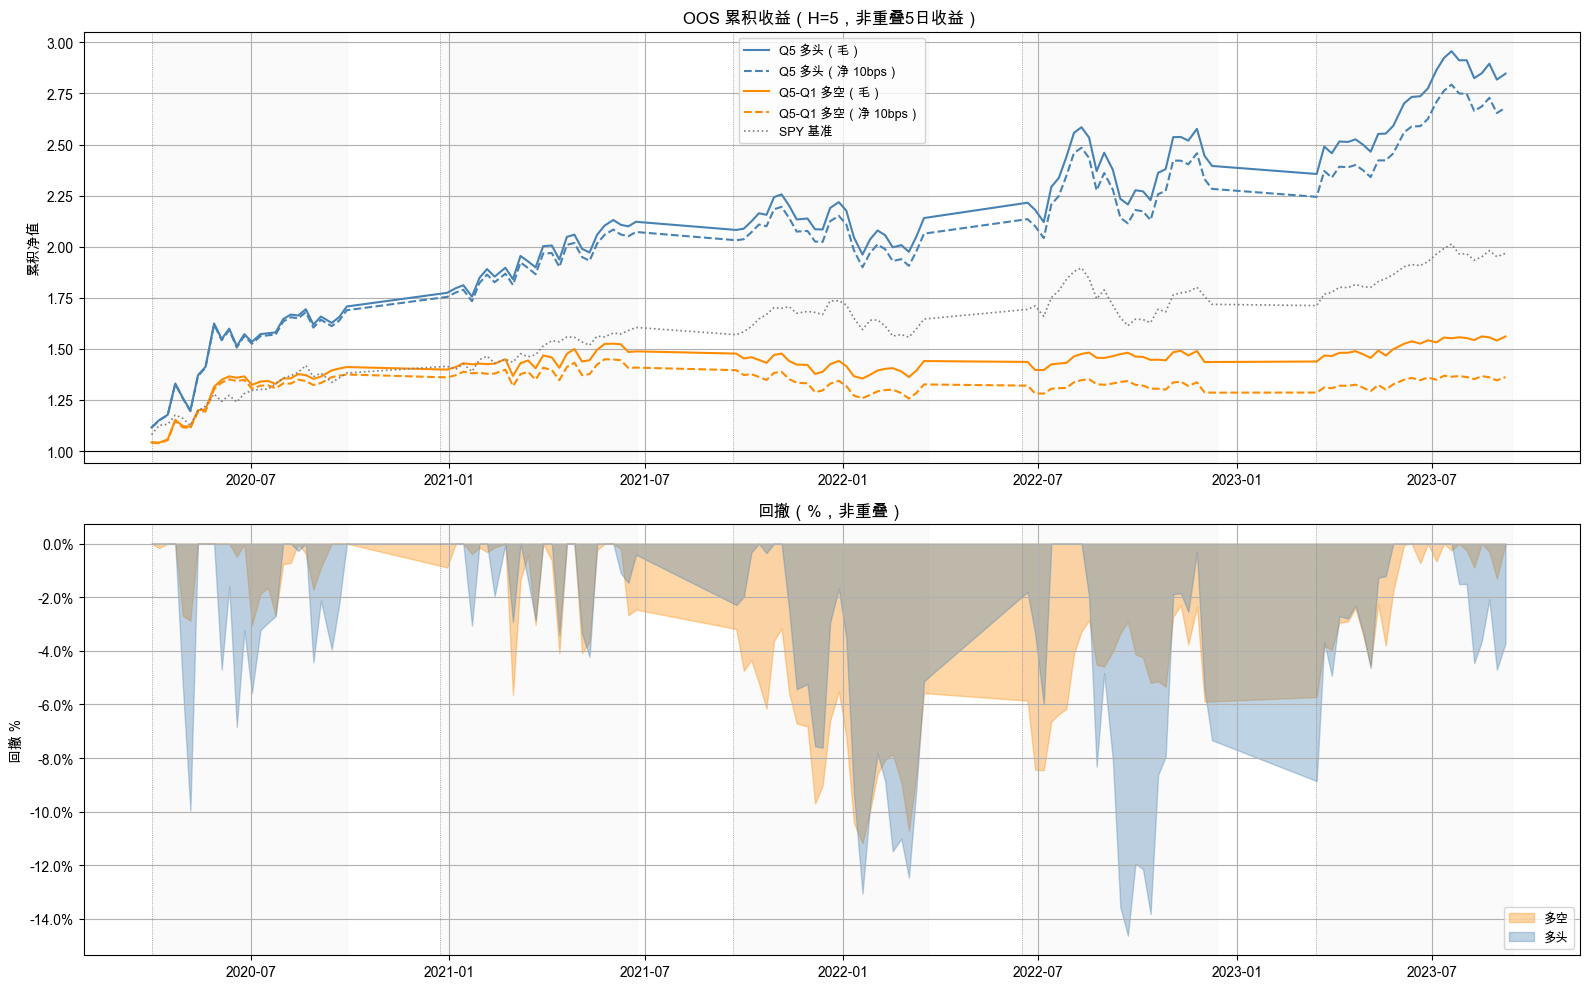

In [36]:
import matplotlib.ticker as mticker

# 非重叠5日收益，修正cost计算（无/2）
cost_10bps_ls   = (to_long + to_short) * 10 / 10000
cost_10bps_long = to_long * 10 / 10000

non_overlap_long     = port["long_ret"].iloc[::HORIZON]
non_overlap_ls       = port["ls_ret"].iloc[::HORIZON]
non_overlap_net_ls   = (port["ls_ret"]   - cost_10bps_ls).iloc[::HORIZON]
non_overlap_net_long = (port["long_ret"] - cost_10bps_long).iloc[::HORIZON]
non_overlap_bm       = port["benchmark_ret"].iloc[::HORIZON]

cumret_long     = (1 + non_overlap_long).cumprod()
cumret_ls       = (1 + non_overlap_ls).cumprod()
cumret_net_ls   = (1 + non_overlap_net_ls).cumprod()
cumret_net_long = (1 + non_overlap_net_long).cumprod()
cumret_bm       = (1 + non_overlap_bm).cumprod()

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

ax = axes[0]
ax.plot(cumret_long.index,     cumret_long,     label="Q5 多头（毛）",         color="steelblue",   lw=1.5)
ax.plot(cumret_net_long.index, cumret_net_long, label="Q5 多头（净 10bps）",   color="steelblue",   lw=1.5, linestyle="--")
ax.plot(cumret_ls.index,       cumret_ls,       label="Q5-Q1 多空（毛）",       color="darkorange",  lw=1.5)
ax.plot(cumret_net_ls.index,   cumret_net_ls,   label="Q5-Q1 多空（净 10bps）", color="darkorange",  lw=1.5, linestyle="--")
ax.plot(cumret_bm.index,       cumret_bm,       label="SPY 基准",               color="gray",        lw=1.2, linestyle=":")
ax.axhline(1, color="k", lw=0.8)
ax.set_title("OOS 累积收益（H=5，非重叠5日收益）", fontsize=12)
ax.set_ylabel("累积净值")
ax.legend(fontsize=9)

for f in folds:
    ax.axvspan(f.test_start, f.test_end, alpha=0.04, color="gray")
    ax.axvline(f.test_start, color="gray", lw=0.5, linestyle=":")

ax2 = axes[1]
dd_ls   = 1 - cumret_ls   / cumret_ls.cummax()
dd_long = 1 - cumret_long / cumret_long.cummax()
ax2.fill_between(dd_ls.index,   -dd_ls   * 100, 0, alpha=0.35, color="darkorange", label="多空")
ax2.fill_between(dd_long.index, -dd_long * 100, 0, alpha=0.35, color="steelblue",  label="多头")
ax2.set_title("回撤（%，非重叠）", fontsize=12)
ax2.set_ylabel("回撤 %")
ax2.legend(fontsize=9)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

for f in folds:
    ax2.axvspan(f.test_start, f.test_end, alpha=0.04, color="gray")
    ax2.axvline(f.test_start, color="gray", lw=0.5, linestyle=":")

plt.tight_layout()
plt.show()

### 6. Pre-Fold 分解

In [40]:
FOLD_NOTES = {
    "fold_001": "2020 新冠崩盘+反弹",
    "fold_002": "2020-21 流动性牛市",
    "fold_003": "2021-22 加息周期开启",
    "fold_004": "2022 熊市",
    "fold_005": "2023 复苏",
}

def _ann(r):    return r.mean() * 252 / 5
def _sharpe(r): return (r.mean() / r.std() * np.sqrt(252/5)) if r.std() > 0 else np.nan

fold_rows = []
for f in folds:
    mask = (port.index >= f.test_start) & (port.index <= f.test_end)
    r_ls   = port.loc[mask, "ls_ret"]
    r_long = port.loc[mask, "long_ret"]
    r_bm   = port.loc[mask, "benchmark_ret"]
    fold_rows.append({
        "fold":       f.fold_id,
        "测试期":     f"{f.test_start.date()} ~ {f.test_end.date()}",
        "市场环境":   FOLD_NOTES[f.fold_id],
        "多空年化":   _ann(r_ls),
        "多空Sharpe": _sharpe(r_ls),
        "多头年化":   _ann(r_long),
        "多头Sharpe": _sharpe(r_long),
        "SPY年化":    _ann(r_bm),
    })

print("=== Per-Fold 绩效 ===")
print(f"{'fold':10s}  {'测试期':25s}  {'多空年化':>8s}  {'多空Sharpe':>10s}  {'多头年化':>8s}  {'多头Sharpe':>10s}  {'SPY年化':>8s}  市场环境")
print("-" * 110)
for v in fold_rows:
    print(
        f"{v['fold']:10s}  {v['测试期']:25s}  {v['多空年化']:8.2%}  {v['多空Sharpe']:10.2f}"
        f"  {v['多头年化']:8.2%}  {v['多头Sharpe']:10.2f}  {v['SPY年化']:8.2%}  {v['市场环境']}"
    )

=== Per-Fold 绩效 ===
fold        测试期                            多空年化    多空Sharpe      多头年化    多头Sharpe     SPY年化  市场环境
--------------------------------------------------------------------------------------------------------------
fold_001    2020-03-31 ~ 2020-09-28      56.09%        2.55   103.90%        2.64    59.20%  2020 新冠崩盘+反弹
fold_002    2020-12-23 ~ 2021-06-24       3.67%        0.26    40.50%        2.25    30.48%  2020-21 流动性牛市
fold_003    2021-09-21 ~ 2022-03-21       2.65%        0.17    12.37%        0.48     7.98%  2021-22 加息周期开启
fold_004    2022-06-16 ~ 2022-12-14       6.40%        0.52    22.75%        0.79     9.16%  2022 熊市
fold_005    2023-03-15 ~ 2023-09-13      20.23%        2.50    37.96%        2.49    25.70%  2023 复苏


### 7. 行业归因

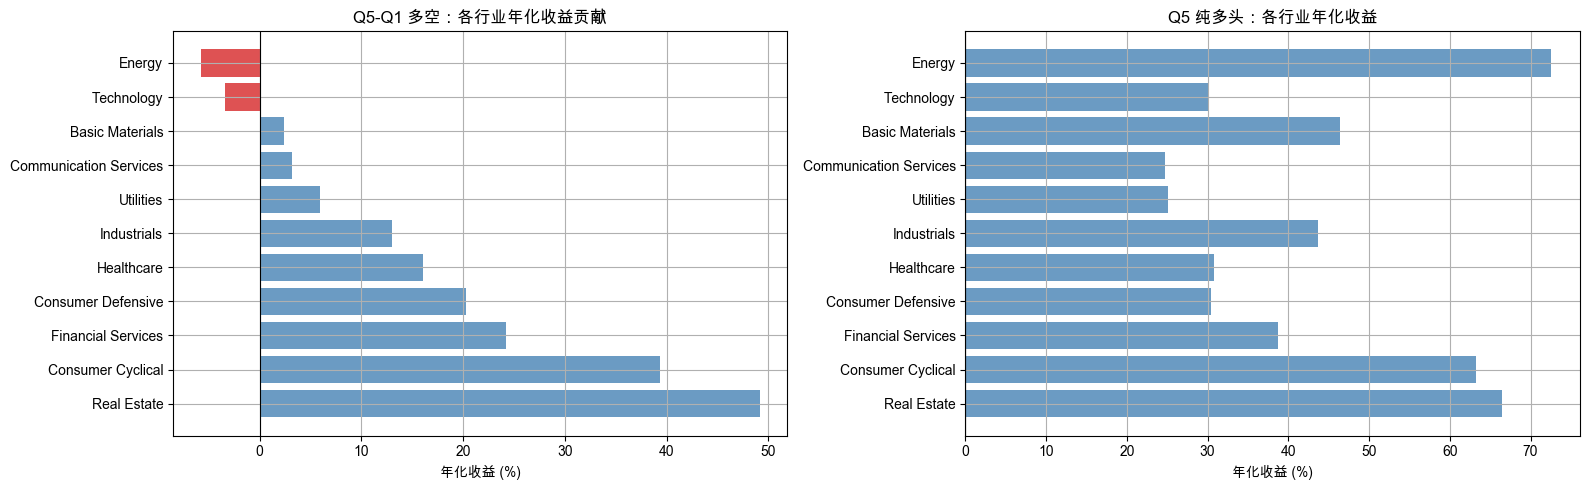

=== 行业收益贡献（年化）===
行业                                多空 Q5-Q1       多头 Q5
-------------------------------------------------------
Real Estate                       +49.12%    +66.47%
Consumer Cyclical                 +39.30%    +63.24%
Financial Services                +24.23%    +38.75%
Consumer Defensive                +20.28%    +30.46%
Healthcare                        +16.08%    +30.80%
Industrials                       +13.00%    +43.73%
Utilities                          +5.93%    +25.09%
Communication Services             +3.15%    +24.70%
Basic Materials                    +2.42%    +46.40%
Technology                         -3.36%    +30.07%
Energy                             -5.78%    +72.50%


In [38]:
# 合并行业信息
pred_q_sector = pred_q.copy()
pred_q_sector["sector"] = pred_q_sector["symbol"].map(sector_map).fillna("Unknown")

long_by_sector  = (pred_q_sector[pred_q_sector["quintile"] == 5]
                   .groupby("sector")["asset_open_to_open_return"].mean())
short_by_sector = (pred_q_sector[pred_q_sector["quintile"] == 1]
                   .groupby("sector")["asset_open_to_open_return"].mean())

ls_ann   = (long_by_sector - short_by_sector).dropna().sort_values(ascending=False) * 252 / 5
long_ann = long_by_sector.reindex(ls_ann.index) * 252 / 5

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title in [
    (axes[0], ls_ann,   "Q5-Q1 多空：各行业年化收益贡献"),
    (axes[1], long_ann, "Q5 纯多头：各行业年化收益"),
]:
    colors = ["steelblue" if v > 0 else "#d62728" for v in data]
    ax.barh(data.index, data * 100, color=colors, alpha=0.8)
    ax.axvline(0, color="k", lw=0.8)
    ax.set_xlabel("年化收益 (%)")
    ax.set_title(title)

plt.tight_layout()
plt.show()

print("=== 行业收益贡献（年化）===")
print(f"{'行业':30s}  {'多空 Q5-Q1':>10s}  {'多头 Q5':>10s}")
print("-" * 55)
for sec in ls_ann.index:
    print(f"{sec:30s}  {ls_ann[sec]:+9.2%}  {long_ann[sec]:+9.2%}")

## 8. 结论

> **评估时间段**：以下所有收益率均基于 5 个非连续 OOS 测试窗口（fold 之间的 gap 期不计入），与买入持有 SPY 全程的年化收益不可直接比较。
>
> - fold_001：2020-03-31 ～ 2020-09-28（新冠崩盘+反弹）
> - fold_002：2020-12-23 ～ 2021-06-24（流动性牛市）
> - fold_003：2021-09-21 ～ 2022-03-21（加息周期开启）
> - fold_004：2022-06-16 ～ 2022-12-14（熊市）
> - fold_005：2023-03-15 ～ 2023-09-13（复苏）

### 核心问题答案

**信号能否在扣除成本后仍产生正收益？**

| 条件 | Q5-Q1 多空 | Q5 纯多头 | SPY 基准 |
|---|---|---|---|
| 毛收益 | 17.81% | 43.50% | 26.50% |
| 净收益 @ 5bps | 15.04% | 42.27% | — |
| 净收益 @ 10bps | 12.28% | 41.03% | — |
| 净收益 @ 20bps | 6.74% | 38.57% | — |

*bps 为单边成本，多空双腿各计买入+卖出两侧。*

**结论**：
- 多空组合在 10bps 成本下净收益 12.3%，但高度依赖 fold_001（新冠）。
- 纯多头组合成本敏感性极低（换手率仅多头腿），20bps 下仍有 38.6%，但含大量市场 beta，不是纯 alpha。
- SPY 同期 26.5%，纯多头跑赢约 17pp，需注意这不是市场中性的超额收益。

### 关键风险点

1. **fold_001 主导收益**：新冠反弹期多空年化 60.9%、纯多头 113.9%，贡献了不成比例的总 P&L。剩余四个 fold 多空年化均值约 8.5%，信号在普通市场环境下明显弱化
2. **换手率极高**：多头 48.8%、空头 60.9%/5天，年化约 2766%，实盘对冲击成本估算误差敏感
3. **容量限制**：100 只股票等权持仓，实盘 AUM 增大后冲击成本未建模

### 与 IC 结果的一致性检验

| Fold | 测试期 | IC | 多空年化 | 多空Sharpe | 一致性 |
|---|---|---|---|---|---|
| fold_001 | 2020-03 ～ 2020-09 | +0.0524 | 60.93% | 3.47 | ✓ 最强 |
| fold_002 | 2020-12 ～ 2021-06 | +0.0085 | 4.45% | 0.44 | ✓ 弱 |
| fold_003 | 2021-09 ～ 2022-03 | −0.0082 | 1.04% | 0.09 | △ IC负但收益微正 |
| fold_004 | 2022-06 ～ 2022-12 | +0.0038 | 8.40% | 0.97 | ✓ 弱正 |
| fold_005 | 2023-03 ～ 2023-09 | +0.0216 | 20.24% | 4.05 | ✓ 较强 |

**注**：fold_003 IC 为负（sector-neutral 维度信号失效），但多空组合收益微正，因为 sector-neutral IC 去除了行业轮动贡献而组合收益保留了。IC 是比组合收益更严格的 alpha 标准。